#MECE

| Member    | Task                            | Description                                                                                   |
| ------------- | ----------------------------------- | ------------------------------------------------------------------------------------------------- |
| Devanshi Adhikari  | Data Preprocessing                  | Download Yelp dataset, extract image-label pairs, resize/normalize images, split train/test sets. |
| Anirudhra Budathoki | kNN Model Development               | Implement k-Nearest Neighbors classifier using image features or embeddings. Evaluate kNN using confusion matrix and AUC; interpret results                      |
| Arjun Kumar    | kNN Tuning                    | Tuning of KNN model                                  |
| Sumith  Padma Padmasree Vijayapadman  | SVM Model Development               | Train SVM on image features (e.g., PCA or embeddings). No tuning required.                        |
| Jeffin John Abraham     | SVM Evaluation                      | Compute confusion matrix and AUC for SVM; analyze performance.                                    |
| Stephen David Chitilapalli Mathew  | DNN Implementation                  | Build and train a deep neural network (fully connected layers) for image classification.          |
| Shabda   Kafle | DNN Evaluation and Tuning           | Evaluate DNN with confusion matrix and AUC; perform hyperparameter tuning.                        |
| Aparna Jayakumar Resmi   | CNN Implementation                  | Design and train a convolutional neural network for image classification.                         |
| Neha  Tamang    | CNN Evaluation and Interpretability | Evaluate CNN using confusion matrix and AUC; apply interpretability techniques.|

# Data Preprocessing

In [ ]:
import os
import pandas as pd
import shutil
import random
from PIL import Image
from tqdm import tqdm
photos_dir = "/content/drive/MyDrive/yelp/photos"
csv_path = "/content/drive/MyDrive/yelp/photos.csv"
output_dir = "/content/yelp_processed"
os.makedirs(output_dir, exist_ok=True)
IMG_SIZE = (224, 224)


In [ ]:
df = pd.read_csv(csv_path)
df = df.dropna(subset=['label'])
df['filename'] = df['photo_id'] + ".jpg"
df = df[df['filename'].apply(lambda x: os.path.isfile(os.path.join(photos_dir, x)))]
print(f"Total valid images found: {len(df)}")


Total valid images found: 69105


In [ ]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
train_df['split'] = 'train'
test_df['split'] = 'test'
full_df = pd.concat([train_df, test_df])


In [ ]:
import concurrent.futures
success_count = 0
failure_count = 0
for split in ['train', 'test']:
    for label in df['label'].unique():
        os.makedirs(os.path.join(output_dir, split, label), exist_ok=True)
def process_and_copy_threaded(row):
    global success_count, failure_count
    src_path = os.path.join(photos_dir, row['filename'])
    dst_path = os.path.join(output_dir, row['split'], row['label'], row['filename'])
    try:
        img = Image.open(src_path).convert("RGB")
        img = img.resize(IMG_SIZE)
        img.save(dst_path)
        return True
    except Exception as e:
        print(f"Skipping {row['filename']} — Error: {str(e)}", flush=True)
        return False
rows = [row for _, row in full_df.iterrows()]
success_count = 0
failure_count = 0

with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
    results = list(tqdm(executor.map(process_and_copy_threaded, rows), total=len(rows)))
success_count = sum(results)
failure_count = len(results) - success_count

print(f"\nFinished processing.")
print(f"Successful: {success_count}")
print(f"Failed: {failure_count}")


  2%|▏         | 1191/69105 [00:31<38:11, 29.64it/s]

Skipping c73YwNh1JsYR5Hz-u_bOrg.jpg — Error: cannot identify image file '/content/drive/MyDrive/yelp/photos/c73YwNh1JsYR5Hz-u_bOrg.jpg'


  6%|▌         | 3942/69105 [01:45<22:53, 47.44it/s]

Skipping 1wd_eyhMrTqUmicDmn4_Kw.jpg — Error: cannot identify image file '/content/drive/MyDrive/yelp/photos/1wd_eyhMrTqUmicDmn4_Kw.jpg'


 10%|▉         | 6768/69105 [03:03<21:18, 48.76it/s]

...

Skipping cNkUV0sInfh_Py5PP8SHtQ.jpg — Error: cannot identify image file '/content/drive/MyDrive/yelp/photos/cNkUV0sInfh_Py5PP8SHtQ.jpg'


100%|█████████▉| 68881/69105 [31:31<00:04, 46.41it/s]

Skipping feUGw0P5byOq4U40C77tyQ.jpg — Error: cannot identify image file '/content/drive/MyDrive/yelp/photos/feUGw0P5byOq4U40C77tyQ.jpg'


100%|██████████| 69105/69105 [31:38<00:00, 36.40it/s]


Finished processing.
Successful: 69070
Failed: 35


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = "/content/yelp_processed/train"
test_dir = "/content/yelp_processed/test"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
# Normalize pixel values (0-1)
datagen = ImageDataGenerator(rescale=1./255)
train_data = datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)


Found 55259 images belonging to 5 classes.
Found 13811 images belonging to 5 classes.


In [ ]:
import shutil
shutil.make_archive('/content/yelp_processed', 'zip', '/content/yelp_processed')


'/content/yelp_processed.zip'

In [ ]:
destination = '/content/drive/MyDrive/yelp_processed.zip'
shutil.copy('/content/yelp_processed.zip', destination)


'/content/drive/MyDrive/yelp_processed.zip'

### Data Processing 2

In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import cv2
from skimage import exposure
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Parameters
IMG_SIZE = 128
IMAGE_DIR = 'photos/'
MAX_IMAGES = 50000

# Load metadata
photos = pd.read_json("photos.json", lines=True)
photos = photos[photos['label'].notna()][['photo_id', 'label']]
le = LabelEncoder()
photos['label'] = le.fit_transform(photos['label'])

# Preprocessing function
def advanced_preprocess(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    img[binary == 0] = 0

    for i in range(3):
        img[:, :, i] = exposure.equalize_hist(img[:, :, i]) * 255

    img = cv2.GaussianBlur(img, (3, 3), 0)
    return img.astype(np.float32) / 255.0

# Process images
images, labels, skipped = [], [], 0
for i, row in enumerate(photos.itertuples(index=False)):
    if i >= MAX_IMAGES:
        break
    path = os.path.join(IMAGE_DIR, f"{row.photo_id}.jpg")
    try:
        img_array = advanced_preprocess(path)
        images.append(img_array)
        labels.append(row.label)
    except:
        skipped += 1
print(f"Finished processing. Skipped: {skipped}")

# Save arrays
X = np.array(images, dtype=np.float32)
y = np.array(labels)
np.save("X_images.npy", X)
np.save("y_labels.npy", y)

Finished processing. Skipped: 29


# Model Building - CNN

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



Epoch 1/10


Epoch 1 - Train Loss: 0.8838 - Val Loss: 0.7006

Epoch 2/10


Epoch 2 - Train Loss: 0.6680 - Val Loss: 0.6285

Epoch 3/10


Epoch 3 - Train Loss: 0.5981 - Val Loss: 0.6345

Epoch 4/10


...

Epoch 6 - Train Loss: 0.4869 - Val Loss: 0.5257

Epoch 7/10


Epoch 7 - Train Loss: 0.4566 - Val Loss: 0.5393

Epoch 8/10


Epoch 8 - Train Loss: 0.4324 - Val Loss: 0.4997

Epoch 9/10


Epoch 9 - Train Loss: 0.4105 - Val Loss: 0.5509

Epoch 10/10


Epoch 10 - Train Loss: 0.3863 - Val Loss: 0.6523

Final Evaluation on Test Set


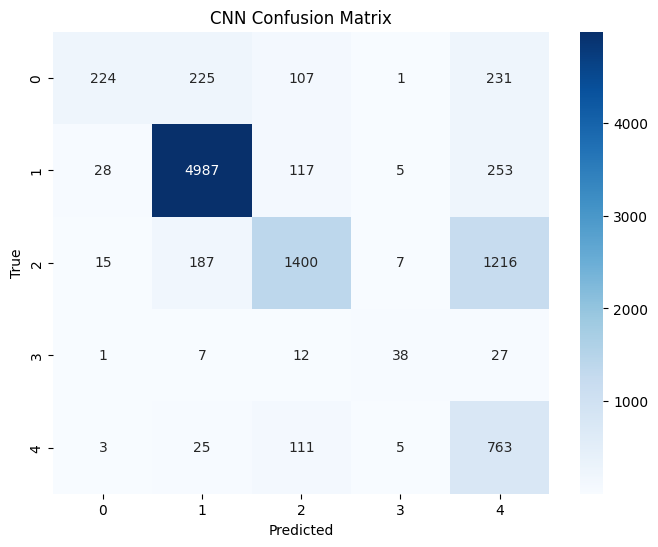

AUC Score: 0.9246


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm

# Dataset class that loads images and labels lazily using memmap and indices
class MemmapDataset(Dataset):
    def __init__(self, image_path, label_path, indices):
        self.X = np.load(image_path, mmap_mode='r')
        self.y = np.load(label_path, mmap_mode='r')
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]
        x = self.X[i].transpose(2, 0, 1)  # Convert HWC to CHW
        y = self.y[i]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

# Load labels to get number of classes and for stratified splits
label_path = '/content/drive/MyDrive/Comp_Vis/y_labels.npy'
image_path = '/content/drive/MyDrive/Comp_Vis/X_images.npy'

all_labels = np.load(label_path, mmap_mode='r')
num_classes = len(np.unique(all_labels))

# Create train/val/test indices with stratification
full_indices = np.arange(len(all_labels))
train_idx, test_idx = train_test_split(full_indices, test_size=0.2, stratify=all_labels, random_state=42)
train_idx, val_idx = train_test_split(train_idx, test_size=0.1, stratify=all_labels[train_idx], random_state=42)

# Create datasets and dataloaders
train_dataset = MemmapDataset(image_path, label_path, train_idx)
val_dataset = MemmapDataset(image_path, label_path, val_idx)
test_dataset = MemmapDataset(image_path, label_path, test_idx)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# CNN model definition
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.fc_layers(self.conv_layers(x))

# Evaluation function (also returns loss if requested)
def evaluate_model(model, data_loader, return_loss=False):
    model.eval()
    preds, probs, labels = [], [], []
    loss_fn = nn.CrossEntropyLoss()
    total_loss = 0
    with torch.no_grad():
        for Xb, yb in data_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            output = model(Xb)
            loss = loss_fn(output, yb)
            total_loss += loss.item()
            prob = torch.softmax(output, dim=1).cpu().numpy()
            pred = np.argmax(prob, axis=1)
            preds.extend(pred)
            probs.extend(prob)
            labels.extend(yb.cpu().numpy())

    if return_loss:
        return total_loss / len(data_loader)

    # Confusion matrix plot
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("CNN Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # AUC score
    y_true_bin = label_binarize(labels, classes=np.arange(num_classes))
    auc = roc_auc_score(y_true_bin, np.array(probs), multi_class='ovr')
    print(f"AUC Score: {auc:.4f}")

# Training function with progress bar and early stopping
def train_model(model, train_loader, val_loader, epochs=10):
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5, verbose=True)
    criterion = nn.CrossEntropyLoss()
    best_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        print(f"\nEpoch {epoch+1}/{epochs}")
        for Xb, yb in tqdm(train_loader, desc="Training", leave=False):
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            output = model(Xb)
            loss = criterion(output, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        val_loss = evaluate_model(model, val_loader, return_loss=True)
        scheduler.step(val_loss)

        print(f"Epoch {epoch+1} - Train Loss: {total_loss/len(train_loader):.4f} - Val Loss: {val_loss:.4f}")

        if val_loss < best_loss:
            best_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= 5:
            print("Early stopping triggered.")
            break

# Initialize and train model
model = ImprovedCNN(num_classes).to(device)
train_model(model, train_loader, val_loader)

# Final evaluation on test set
print("\nFinal Evaluation on Test Set")
evaluate_model(model, test_loader)

AUC Score: 0.9246

## CNN Evaluation and Tuning

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import label_binarize

In [ ]:
# Load data
X = np.load("/content/drive/MyDrive/X_images.npy", mmap_mode='r')[:10000]
y = np.load('/content/drive/MyDrive/y_labels.npy')[:10000]
num_classes = len(np.unique(y))

In [ ]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, stratify=y, random_state=42
 )


In [ ]:
# PyTorch Tensors: (N, C, H, W)
X_train = torch.tensor(X_train.transpose(0, 3, 1, 2), dtype=torch.float32)
X_test = torch.tensor(X_test.transpose(0, 3, 1, 2), dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=64)

In [ ]:
# CNN Model
class CNNModel(nn.Module):
    def __init__(self, num_classes):
        super(CNNModel, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        return self.fc_layers(x)

In [ ]:
# Evaluate
model.eval()
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

        all_preds.extend(preds)
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

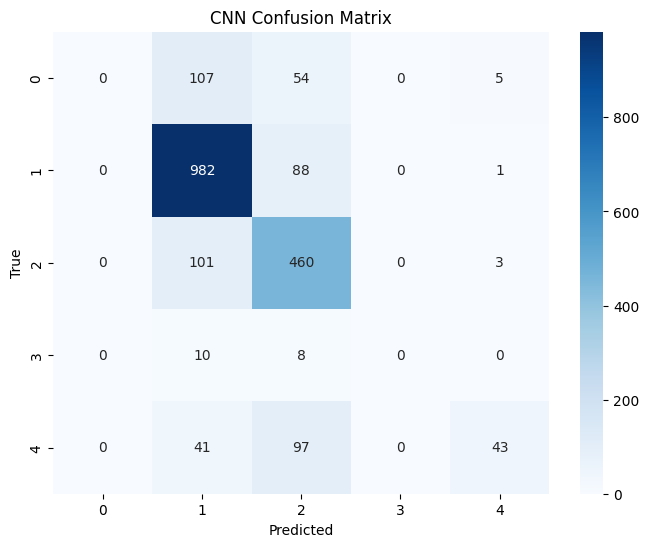

In [ ]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('CNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
# AUC Score (Multiclass One-vs-Rest)
y_true_bin = label_binarize(all_labels, classes=np.arange(num_classes))
y_probs = np.array(all_probs)

auc_score = roc_auc_score(y_true_bin, y_probs, multi_class='ovr')
print(f"CNN Multiclass AUC Score: {auc_score:.4f}")

CNN Multiclass AUC Score: 0.8217


In [ ]:
def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=10, device='cpu'):
    model.to(device)
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
        epoch_loss = running_loss / len(train_loader.dataset)
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}')

    print("Finished Training")

In [ ]:
# Evaluate the trained model
model.eval()
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)

            all_preds.extend(preds)
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
# Evaluate the trained model
model.eval()
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)

            all_preds.extend(preds)
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

auc_score = roc_auc_score(label_binarize(all_labels, classes=np.arange(num_classes)), np.array(all_probs), multi_class='ovr')
print(f"CNN Multiclass AUC Score: {auc_score:.4f}")

Confusion Matrix:
[[  0 107  54   0   5]
 [  0 982  88   0   1]
 [  0 101 460   0   3]
 [  0  10   8   0   0]
 [  0  41  97   0  43]]
CNN Multiclass AUC Score: 0.8217


In [ ]:
#tuning different learning rates and batch sizes
learning_rates = [0.01, 0.001, 0.0001]
batch_sizes = [32, 64, 128]
results = {}

device = "cuda" if torch.cuda.is_available() else "cpu"

for lr in learning_rates:
    for bs in batch_sizes:
        print(f"Training with Learning Rate: {lr}, Batch Size: {bs}")
        # Create new DataLoaders with the current batch size
        train_loader_tuned = DataLoader(TensorDataset(X_train, y_train), batch_size=bs, shuffle=True)
        test_loader_tuned = DataLoader(TensorDataset(X_test, y_test), batch_size=bs)

        model_tuned = CNNModel(num_classes)
        criterion = nn.CrossEntropyLoss()
        optimizer_tuned = optim.Adam(model_tuned.parameters(), lr=lr)

Training with Learning Rate: 0.01, Batch Size: 32
Training with Learning Rate: 0.01, Batch Size: 64
Training with Learning Rate: 0.01, Batch Size: 128
Training with Learning Rate: 0.001, Batch Size: 32
Training with Learning Rate: 0.001, Batch Size: 64
Training with Learning Rate: 0.001, Batch Size: 128
Training with Learning Rate: 0.0001, Batch Size: 32
Training with Learning Rate: 0.0001, Batch Size: 64
Training with Learning Rate: 0.0001, Batch Size: 128


In [ ]:
 # The train_model function now returns cm and auc_score
cm_tuned, auc_score_tuned = train_model(model_tuned, train_loader_tuned, test_loader_tuned, criterion, optimizer_tuned, num_epochs=5, device=device)

results[(lr, bs)] = {'confusion_matrix': cm_tuned, 'auc_score': auc_score_tuned}
print(f"  AUC Score: {auc_score_tuned:.4f}")


Epoch 1/5, Loss: 0.6774
Epoch 2/5, Loss: 0.6580
Epoch 3/5, Loss: 0.6322
Epoch 4/5, Loss: 0.6159
Epoch 5/5, Loss: 0.5835
Finished Training
  AUC Score: 0.9093


## CNN Interpretability

  0%|          | 0/1000 [00:00<?, ?it/s]

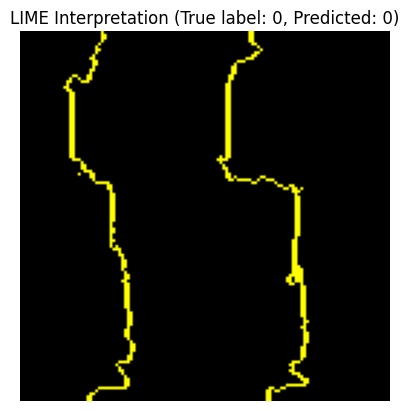

In [ ]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
import torch

# Select a sample index from test dataset
sample_idx = 500

# Since your MemmapDataset returns (C,H,W) tensors, convert to (H,W,C) numpy image for LIME
img_tensor, true_label = test_dataset[sample_idx]
img_np = img_tensor.permute(1, 2, 0).numpy()

# Define prediction function for LIME
def batch_predict(images):
    # images: list or numpy array of images (N, H, W, C) with pixel values 0-255 usually
    model.eval()
    batch = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)  # NHWC -> NCHW
    with torch.no_grad():
        logits = model(batch)
        probs = torch.softmax(logits, dim=1)
    return probs.cpu().numpy()

# Initialize LIME explainer
explainer = lime_image.LimeImageExplainer()

# Run explanation on the sample image
explanation = explainer.explain_instance(
    img_np.astype(np.double),    # lime expects double precision float
    classifier_fn=batch_predict,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

# Get mask and image with boundaries for the top predicted label
temp, mask = explanation.get_image_and_mask(
    label=explanation.top_labels[0],
    positive_only=True,
    hide_rest=False,
    num_features=10,
    min_weight=0.0
)

# Plot the explanation
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title(f"LIME Interpretation (True label: {true_label.item()}, Predicted: {explanation.top_labels[0]})")
plt.axis('off')
plt.show()

# Model Building - SVM

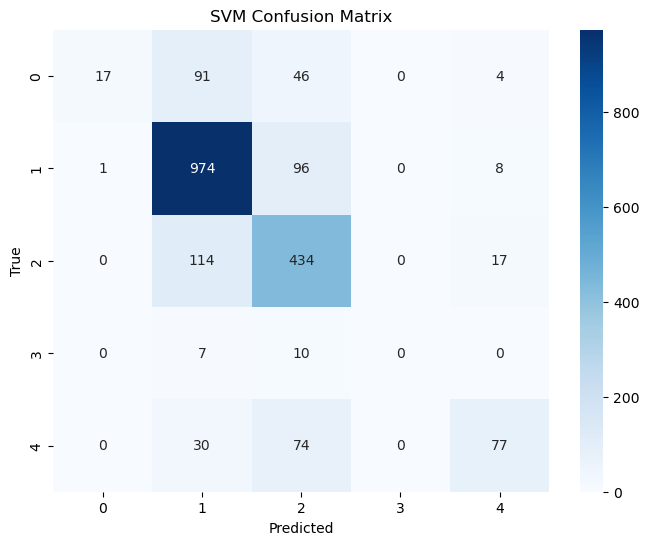

SVM Multiclass AUC Score: 0.8687


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.decomposition import PCA

# Load preprocessed data
X = np.load('X_images.npy')
y = np.load('y_labels.npy')
num_classes = len(np.unique(y))

# Sample 10000 images
X_sample, _, y_sample, _ = train_test_split(X, y, train_size=10000, stratify=y, random_state=42)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2, stratify=y_sample, random_state=42)

# Flatten images (N, C, H, W) -> (N, C*H*W)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Optional: PCA for dimensionality reduction
pca = PCA(n_components=0.95)  # Keep 95% of variance
X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca = pca.transform(X_test_flat)

# Train SVM Model
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_pca, y_train)

# Predictions and probability outputs
y_preds = svm_model.predict(X_test_pca)
y_probs = svm_model.predict_proba(X_test_pca)

# Confusion Matrix
cm = confusion_matrix(y_test, y_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# AUC Score (Multiclass One-vs-Rest)
y_true_bin = label_binarize(y_test, classes=np.arange(num_classes))
auc_score = roc_auc_score(y_true_bin, y_probs, multi_class='ovr')
print(f"SVM Multiclass AUC Score: {auc_score:.4f}")

SVM Multiclass AUC Score: 0.8687

## SVM Model Evaluation


In [ ]:
import pandas as pd

image_extract_path = '/content/yelp_images'

json_path = os.path.join(image_extract_path, 'photos.json')
df = pd.read_json(json_path, lines=True)

target_labels = ['food', 'drink', 'menu', 'inside']
df_filtered = df[df['label'].isin(target_labels)]

df_sampled = df_filtered.groupby('label').apply(lambda x: x.sample(n=1250, random_state=42)).reset_index(drop=True)

print("Total images selected:", len(df_sampled))


Total images selected: 5000


<ipython-input-4-1a825693c33e>:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df_filtered.groupby('label').apply(lambda x: x.sample(n=1250, random_state=42)).reset_index(drop=True)


In [ ]:
import numpy as np
import cv2
from tqdm import tqdm

IMG_SIZE = 64
image_dir = os.path.join(image_extract_path, 'photos')
X = []
y = []

for idx, row in tqdm(df_sampled.iterrows(), total=len(df_sampled)):
    img_id = row['photo_id']
    label = row['label']
    img_path = os.path.join(image_dir, img_id + '.jpg')

    try:
        img = cv2.imread(img_path)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0
        X.append(img.flatten())
        y.append(label)
    except:
        continue

X = np.array(X)
y = np.array(y)

print("Loaded images:", X.shape[0])
print("Feature shape per image:", X.shape[1])


100%|██████████| 5000/5000 [00:26<00:00, 191.97it/s]


Loaded images: 4996
Feature shape per image: 12288


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=200, random_state=42)
X_pca = pca.fit_transform(X)
print("PCA-reduced shape:", X_pca.shape)


PCA-reduced shape: (4996, 200)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_pca, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42)


In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)
print("SVM model training completed.")


SVM model training completed.


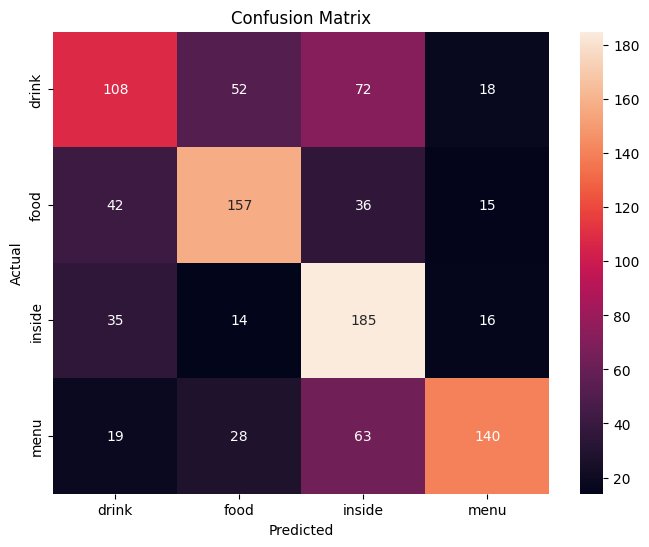

              precision    recall  f1-score   support

       drink       0.53      0.43      0.48       250
        food       0.63      0.63      0.63       250
      inside       0.52      0.74      0.61       250
        menu       0.74      0.56      0.64       250

    accuracy                           0.59      1000
   macro avg       0.60      0.59      0.59      1000
weighted avg       0.60      0.59      0.59      1000

Macro-Averaged AUC Score: 0.8286


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = svm_model.predict(X_test)
y_prob = svm_model.predict_proba(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred, target_names=le.classes_))

y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
auc = roc_auc_score(y_test_bin, y_prob, average='macro', multi_class='ovr')
print("Macro-Averaged AUC Score:", round(auc, 4))


# Model Building - DNN

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Custom Dataset for DNN that flattens image
class MemmapDNNFlatDataset(Dataset):
    def __init__(self, image_path, label_path, indices):
        self.X = np.load(image_path, mmap_mode='r')
        self.y = np.load(label_path, mmap_mode='r')
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]
        x = self.X[i].transpose(2, 0, 1).reshape(-1)  # HWC → CHW → flat
        y = self.y[i]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

# Paths
image_path = '/content/drive/MyDrive/X_images.npy'
label_path = '/content/drive/MyDrive/y_labels.npy'

# Load labels and split
all_labels = np.load(label_path, mmap_mode='r')
num_classes = len(np.unique(all_labels))

indices = np.arange(len(all_labels))
train_idx, test_idx = train_test_split(indices, test_size=0.2, stratify=all_labels, random_state=42)
train_idx, val_idx = train_test_split(train_idx, test_size=0.1, stratify=all_labels[train_idx], random_state=42)

# Datasets and Loaders
train_dataset = MemmapDNNFlatDataset(image_path, label_path, train_idx)
val_dataset = MemmapDNNFlatDataset(image_path, label_path, val_idx)
test_dataset = MemmapDNNFlatDataset(image_path, label_path, test_idx)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

# DNN Model
class DNNModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# Evaluation
def evaluate_model(model, data_loader, return_loss=False):
    model.eval()
    preds, probs, labels = [], [], []
    criterion = nn.CrossEntropyLoss()
    total_loss = 0
    with torch.no_grad():
        for Xb, yb in data_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            out = model(Xb)
            loss = criterion(out, yb)
            total_loss += loss.item()
            prob = torch.softmax(out, dim=1).cpu().numpy()
            pred = np.argmax(prob, axis=1)
            preds.extend(pred)
            probs.extend(prob)
            labels.extend(yb.cpu().numpy())

    if return_loss:
        return total_loss / len(data_loader)

    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
    plt.title("DNN Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    y_true_bin = label_binarize(labels, classes=np.arange(num_classes))
    auc = roc_auc_score(y_true_bin, np.array(probs), multi_class='ovr')
    print(f"DNN AUC Score: {auc:.4f}")

# Training
def train_model(model, train_loader, val_loader, epochs=10):
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)
    criterion = nn.CrossEntropyLoss()
    best_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        print(f"\nEpoch {epoch+1}/{epochs}")
        for Xb, yb in tqdm(train_loader, desc="Training", leave=False):
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(Xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        val_loss = evaluate_model(model, val_loader, return_loss=True)
        scheduler.step(val_loss)
        print(f"Train Loss: {total_loss/len(train_loader):.4f} - Val Loss: {val_loss:.4f}")

        if val_loss < best_loss:
            best_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= 5:
            print("Early stopping triggered.")
            break

# Run training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sample_input, _ = train_dataset[0]
input_dim = sample_input.shape[0]

model = DNNModel(input_dim=input_dim, num_classes=num_classes).to(device)
train_model(model, train_loader, val_loader)

# Final Test Evaluation
print("\nFinal Test Evaluation")
evaluate_model(model, test_loader)


Epoch 1/10


Train Loss: 1.2412 - Val Loss: 1.1523

Epoch 2/10


Train Loss: 1.1753 - Val Loss: 1.1270

Epoch 3/10


Train Loss: 1.1546 - Val Loss: 1.1296

Epoch 4/10


Train Loss: 1.1398 - Val Loss: 1.1009

Epoch 5/10


Train Loss: 1.1205 - Val Loss: 1.0837

Epoch 6/10


Train Loss: 1.1064 - Val Loss: 1.0704

Epoch 7/10


Training:  64%|██████▎   | 358/563 [07:13<04:21,  1.28s/it]

## DNN Evaluation and Tuning

In [ ]:
#Evaluation

from sklearn.metrics import classification_report

model.eval()
all_preds = []
all_probs = []
all_targets = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_preds.append(torch.argmax(probs, dim=1).cpu().numpy())
        all_targets.append(labels.cpu().numpy())

In [ ]:
# Stack all batches
y_pred = np.concatenate(all_preds)
y_probs = np.concatenate(all_probs)
y_true = np.concatenate(all_targets)

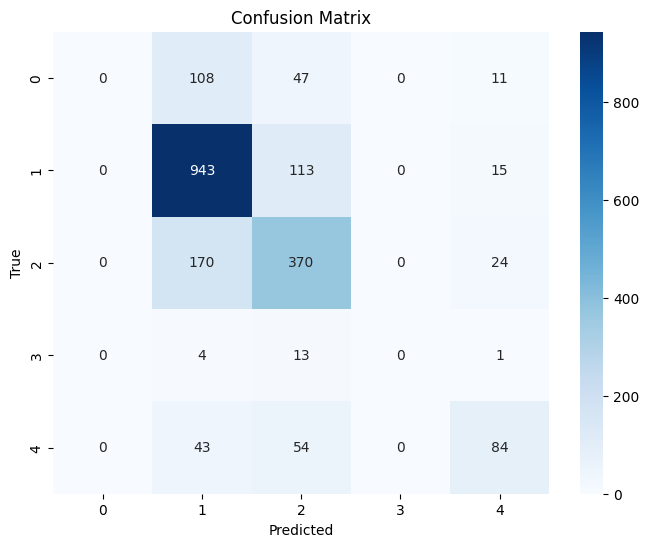

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Classification Report
print("\nClassification Report:\n", classification_report(y_true, y_pred))



Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       166
           1       0.74      0.88      0.81      1071
           2       0.62      0.66      0.64       564
           3       0.00      0.00      0.00        18
           4       0.62      0.46      0.53       181

    accuracy                           0.70      2000
   macro avg       0.40      0.40      0.40      2000
weighted avg       0.63      0.70      0.66      2000



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# AUC Score (One-vs-Rest)
try:
    y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
    auc = roc_auc_score(y_true_bin, y_probs, multi_class='ovr')
    print(f"\nAUC Score (One-vs-Rest): {auc:.4f}")
except Exception as e:
    print(f"\nAUC could not be computed: {e}")


AUC Score (One-vs-Rest): 0.7915


In [ ]:
#tuning 1: changing the epoch to 20

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train_dnn.shape[1]
model = DNNModel(input_dim=input_dim, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 20
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"[DNN] Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss / len(train_loader):.4f}")

[DNN] Epoch 1/20, Loss: 1.1816
[DNN] Epoch 2/20, Loss: 1.0601
[DNN] Epoch 3/20, Loss: 1.0226
[DNN] Epoch 4/20, Loss: 0.9899
[DNN] Epoch 5/20, Loss: 0.9727
[DNN] Epoch 6/20, Loss: 0.9572
[DNN] Epoch 7/20, Loss: 0.9414
[DNN] Epoch 8/20, Loss: 0.9324
[DNN] Epoch 9/20, Loss: 0.9214
[DNN] Epoch 10/20, Loss: 0.9120
[DNN] Epoch 11/20, Loss: 0.9069
[DNN] Epoch 12/20, Loss: 0.8952
[DNN] Epoch 13/20, Loss: 0.8821
[DNN] Epoch 14/20, Loss: 0.8831
[DNN] Epoch 15/20, Loss: 0.8737
[DNN] Epoch 16/20, Loss: 0.8683
[DNN] Epoch 17/20, Loss: 0.8721
[DNN] Epoch 18/20, Loss: 0.8686
[DNN] Epoch 19/20, Loss: 0.8490
[DNN] Epoch 20/20, Loss: 0.8396


In [ ]:
#Evaluation 1

from sklearn.metrics import classification_report

model.eval()
all_preds = []
all_probs = []
all_targets = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_preds.append(torch.argmax(probs, dim=1).cpu().numpy())
        all_targets.append(labels.cpu().numpy())

# Stack all batches
y_pred = np.concatenate(all_preds)
y_probs = np.concatenate(all_probs)
y_true = np.concatenate(all_targets)

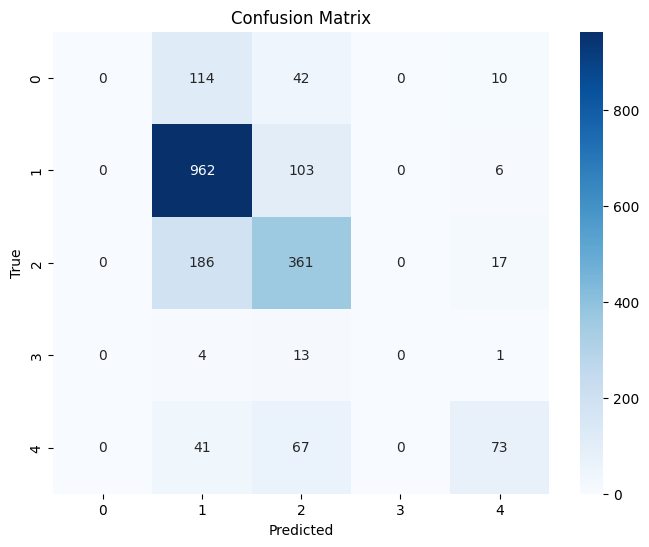

In [ ]:
# Confusion matrix 1
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Classification Report 1
print("\nClassification Report:\n", classification_report(y_true, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       166
           1       0.74      0.90      0.81      1071
           2       0.62      0.64      0.63       564
           3       0.00      0.00      0.00        18
           4       0.68      0.40      0.51       181

    accuracy                           0.70      2000
   macro avg       0.41      0.39      0.39      2000
weighted avg       0.63      0.70      0.66      2000



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# AUC Score (One-vs-Rest) 1
try:
    y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
    auc = roc_auc_score(y_true_bin, y_probs, multi_class='ovr')
    print(f"\nAUC Score (One-vs-Rest): {auc:.4f}")
except Exception as e:
    print(f"\nAUC could not be computed: {e}")


AUC Score (One-vs-Rest): 0.7925


In [ ]:
#tuning 2: changing the epoch to 10 and adjusting the dropout rate

# DNN MODEL
class tunedDNNModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(tunedDNNModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# Training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train_dnn.shape[1]
model = tunedDNNModel(input_dim=input_dim, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 10
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"[DNN] Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss / len(train_loader):.4f}")

[DNN] Epoch 1/10, Loss: 1.1058
[DNN] Epoch 2/10, Loss: 0.9802
[DNN] Epoch 3/10, Loss: 0.9433
[DNN] Epoch 4/10, Loss: 0.9150
[DNN] Epoch 5/10, Loss: 0.8874
[DNN] Epoch 6/10, Loss: 0.9028
[DNN] Epoch 7/10, Loss: 0.8579
[DNN] Epoch 8/10, Loss: 0.8516
[DNN] Epoch 9/10, Loss: 0.8349
[DNN] Epoch 10/10, Loss: 0.8186


In [ ]:
#Evaluation 2

from sklearn.metrics import classification_report

model.eval()
all_preds = []
all_probs = []
all_targets = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_preds.append(torch.argmax(probs, dim=1).cpu().numpy())
        all_targets.append(labels.cpu().numpy())

# Stack all batches
y_pred = np.concatenate(all_preds)
y_probs = np.concatenate(all_probs)
y_true = np.concatenate(all_targets)

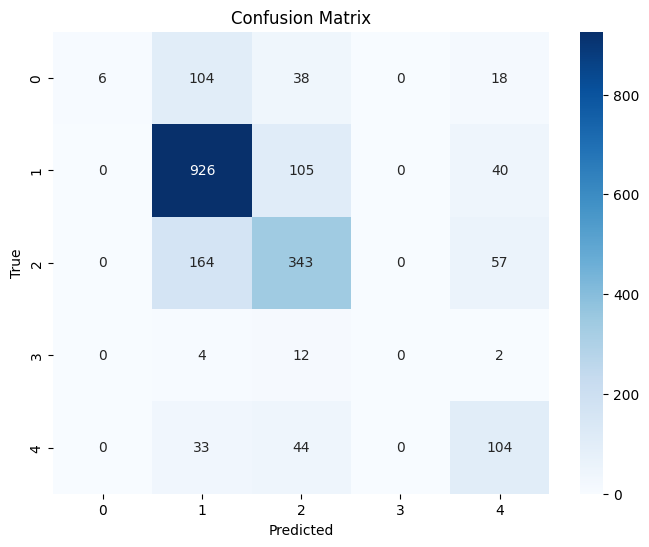

In [ ]:
# Confusion matrix 2
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Classification Report 2
print("\nClassification Report:\n", classification_report(y_true, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.04      0.07       166
           1       0.75      0.86      0.80      1071
           2       0.63      0.61      0.62       564
           3       0.00      0.00      0.00        18
           4       0.47      0.57      0.52       181

    accuracy                           0.69      2000
   macro avg       0.57      0.42      0.40      2000
weighted avg       0.71      0.69      0.66      2000



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# AUC Score (One-vs-Rest) 2
try:
    y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
    auc = roc_auc_score(y_true_bin, y_probs, multi_class='ovr')
    print(f"\nAUC Score (One-vs-Rest): {auc:.4f}")
except Exception as e:
    print(f"\nAUC could not be computed: {e}")


AUC Score (One-vs-Rest): 0.8030


In [ ]:
#tuning 3: adding the extra layer and changing the epoch to 10
class TunedDNNModel(nn.Module):
    def __init__(self, input_dim, num_classes, dropout_rate=0.3):
        super(TunedDNNModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# Training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train_dnn.shape[1]
model = TunedDNNModel(input_dim=input_dim, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 10
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"[DNN] Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss / len(train_loader):.4f}")



[DNN] Epoch 1/10, Loss: 1.2028
[DNN] Epoch 2/10, Loss: 0.9693
[DNN] Epoch 3/10, Loss: 0.9045
[DNN] Epoch 4/10, Loss: 0.8561
[DNN] Epoch 5/10, Loss: 0.8081
[DNN] Epoch 6/10, Loss: 0.7557
[DNN] Epoch 7/10, Loss: 0.7101
[DNN] Epoch 8/10, Loss: 0.6658
[DNN] Epoch 9/10, Loss: 0.6321
[DNN] Epoch 10/10, Loss: 0.5783


In [ ]:
#Evaluation 3

from sklearn.metrics import classification_report

model.eval()
all_preds = []
all_probs = []
all_targets = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_preds.append(torch.argmax(probs, dim=1).cpu().numpy())
        all_targets.append(labels.cpu().numpy())

# Stack all batches
y_pred = np.concatenate(all_preds)
y_probs = np.concatenate(all_probs)
y_true = np.concatenate(all_targets)

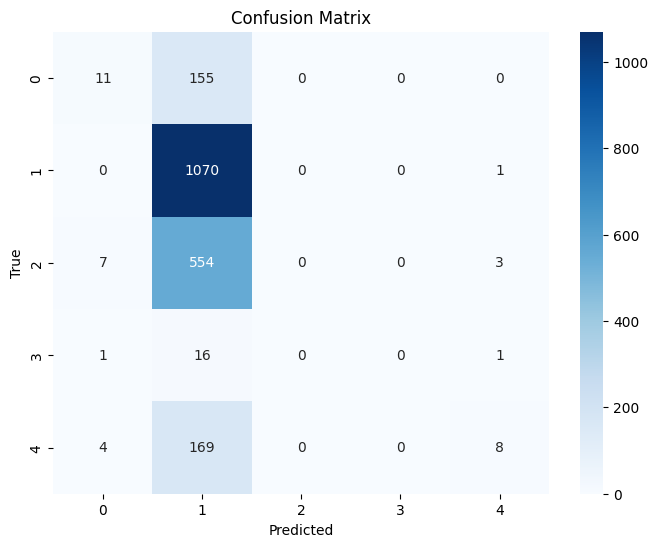

In [ ]:
# Confusion matrix 3
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Classification Report 3
print("\nClassification Report:\n", classification_report(y_true, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.07      0.12       166
           1       0.54      1.00      0.71      1071
           2       0.00      0.00      0.00       564
           3       0.00      0.00      0.00        18
           4       0.62      0.04      0.08       181

    accuracy                           0.54      2000
   macro avg       0.33      0.22      0.18      2000
weighted avg       0.39      0.54      0.39      2000



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# AUC Score (One-vs-Rest) 3
try:
    y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
    auc = roc_auc_score(y_true_bin, y_probs, multi_class='ovr')
    print(f"\nAUC Score (One-vs-Rest): {auc:.4f}")
except Exception as e:
    print(f"\nAUC could not be computed: {e}")


AUC Score (One-vs-Rest): 0.7242


# Model Building - KNN

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

In [ ]:
#SET PATHS
photos_dir = 'photos'  # Directory containing photo files
photos_json = 'photos.json'  # Path to JSON file
output_dir = 'preprocessed_data'  # Where to save processed data
os.makedirs(output_dir, exist_ok=True)

In [ ]:
# Constants
IMG_SIZE = 128  # For CNN
MAX_IMAGES = 50000

# Load JSONL file (each line is a JSON object)
photos_data = []
with open(photos_json, 'r') as f:
    for line in f:
        try:
            photos_data.append(json.loads(line.strip()))
        except json.JSONDecodeError as e:
            print(f'Error parsing line: {e}')
            continue

# Convert to DataFrame
photos_df = pd.DataFrame(photos_data)
photos_df = photos_df.sample(n=20000, random_state=42).reset_index(drop=True)

print('Sampled DataFrame shape:', photos_df.shape)
print(photos_df.head())


Sampled DataFrame shape: (20000, 4)
                 photo_id             business_id              caption  label
0  k_PSngRS22mSA1MypwrjPg  DzzVSYXadZ1_XgfGz_Loyw  Chocolate Croissant   food
1  D_94KivwVgitkzFIgE_KcQ  Xdzir62WKlSzeu4PMQtlBA                        food
2  Hf39P7_G_eRCqfVwvMDV6g  z0HzwNBmx_BgdiYI4hLk3g    Happy Anniversary  drink
3  agxl4sABeRXwjLL506KMrQ  HzRSWmNxcEVQGrr1tun25w       Frozen Puccino   food
4  7cZ0MREN2TwAAX4nnirQlA  aj0urA2r2WlqZKufeB5dpw  Double Cheeseburger   food


In [ ]:
# Label distribution
print("\nLabel distribution:\n", photos_df['label'].value_counts())

# Check missing values and caption lengths
print("\nMissing captions:", photos_df['caption'].isnull().sum())
print("\nCaption length stats:\n", photos_df['caption'].str.len().describe())


Label distribution:
 label
food       10877
inside      5550
outside     1850
drink       1550
menu         173
Name: count, dtype: int64

Missing captions: 0

Caption length stats:
 count    20000.000000
mean        14.999000
std         24.376036
min          0.000000
25%          0.000000
50%          0.000000
75%         21.000000
max        140.000000
Name: caption, dtype: float64


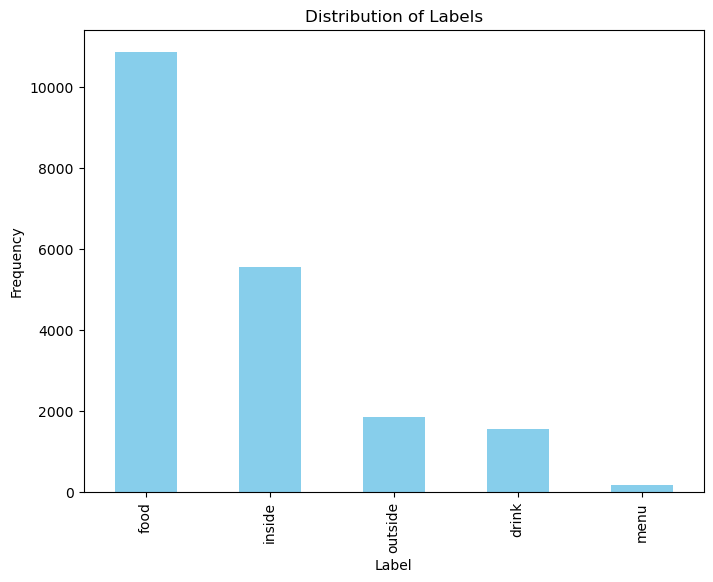

In [ ]:
# Plot label distribution
import matplotlib.pyplot as plt

label_counts = photos_df['label'].value_counts()
plt.figure(figsize=(8, 6))
label_counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of Labels')
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.show()

<Figure size 1000x600 with 0 Axes>

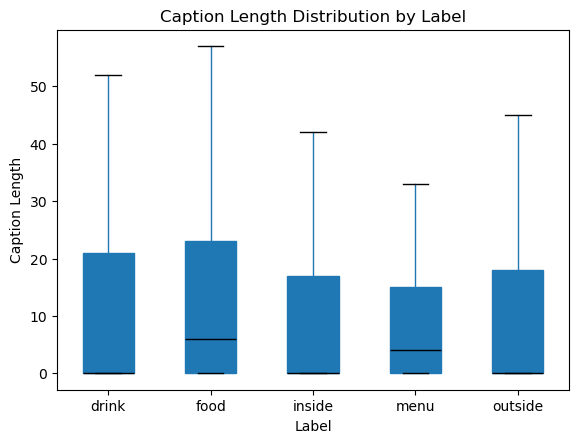

In [ ]:
# Caption length boxplot
photos_df['caption_length'] = photos_df['caption'].str.len()
plt.figure(figsize=(10, 6))
photos_df.boxplot(column='caption_length', by='label', grid=False, showfliers=False, patch_artist=True, medianprops={'color': 'black'})
plt.title('Caption Length Distribution by Label')
plt.suptitle('')
plt.xlabel('Label')
plt.ylabel('Caption Length')
plt.show()

In [ ]:
# Unique businesses by label
business_by_label = photos_df.groupby('label')['business_id'].nunique()
print("\nUnique businesses per label:\n", business_by_label)


Unique businesses per label:
 label
drink      1382
food       7458
inside     4239
menu        166
outside    1559
Name: business_id, dtype: int64


In [ ]:
# Encode labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
photos_df['label'] = le.fit_transform(photos_df['label'])

In [ ]:
# Process images
images = []
labels = []
skipped_count = 0
total = min(MAX_IMAGES, len(photos_df))

print(f"\nTotal images to process: {total}")

for i, row in enumerate(photos_df.itertuples(index=False)):
    if i >= MAX_IMAGES:
        break

    img_path = os.path.join(photos_dir, f"{row.photo_id}.jpg")  #  use photo_id

    try:
        with Image.open(img_path) as img:
            img = img.convert('RGB')
            img = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
            img_array = np.asarray(img, dtype=np.float32) / 255.0  # Normalize
            images.append(img_array)
            labels.append(row.label)
    except Exception as e:
        skipped_count += 1
        print(f"Failed to process {img_path}: {e}")

    if i % (total // 20 or 1) == 0 or i == total - 1:
        percent = (i + 1) / total * 100
        print(f"Progress: {percent:.1f}% ({i + 1}/{total})", end='\r')

print(f"\n\nFinished processing {len(images)} images.")
print(f"Skipped {skipped_count} corrupted/unreadable images.")


Total images to process: 20000
Failed to process photos\1MOGQBWogR8oJr1WgERi9g.jpg: cannot identify image file 'C:\\Users\\aniru\\Downloads\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos\\1MOGQBWogR8oJr1WgERi9g.jpg'
Failed to process photos\pW1IPuTdLIUB61goirbXaA.jpg: cannot identify image file 'C:\\Users\\aniru\\Downloads\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos\\pW1IPuTdLIUB61goirbXaA.jpg'
Failed to process photos\CBxmBYD_5CXIL_F-2PDqmA.jpg: cannot identify image file 'C:\\Users\\aniru\\Downloads\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos\\CBxmBYD_5CXIL_F-2PDqmA.jpg'
Failed to process photos\W94rrCn0O5K1lkfD26m4tw.jpg: cannot identify image file 'C:\\Users\\aniru\\Downloads\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos\\W94rrCn0O5K1lkfD26m4tw.jpg'
Failed to process photos\7xcWPjcE4mxoQ1AjvvKJZg.jpg: cannot identify image file 'C:\\Users\\aniru\\Downloads\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos\\7xcWPjcE4mxoQ1AjvvKJZg.jpg'
Failed to process photos\JZZ716oX6_MqH6L_Mk

In [ ]:
test_path = os.path.join(photos_dir, f"{photos_df.iloc[0].photo_id}.jpg")
print("Test path:", test_path)

try:
    with Image.open(test_path) as img:
        img = img.convert('RGB')
        img = img.resize((64, 64))
        img_array = np.asarray(img, dtype=np.float32) / 255.0
        print("Image shape:", img_array.shape)
except Exception as e:
    print("Error:", e)


Test path: photos\k_PSngRS22mSA1MypwrjPg.jpg
Image shape: (64, 64, 3)


In [ ]:
# 1. Flatten image arrays
X = np.array(images).reshape(len(images), -1)  # (num_samples, 64*64*3)
y = np.array(labels)


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV


In [ ]:
#create sample data if you're just testing
import numpy as np
X = np.random.rand(100, 4)  # Create 100 samples with 4 features
y = np.random.randint(0, 2, 100)  # Binary target variable

# Now split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# 3. Train KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)


KNeighborsClassifier()

In [ ]:
# 4. Predict and evaluate
y_pred = knn.predict(X_test)


In [ ]:
distances, indices = knn.kneighbors([X_test[0]])
print("Nearest labels:", y_train[indices])


Nearest labels: [[0 1 0 1 1]]


## KNN Evaluation

In [ ]:
print("\n--- Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("Classification Report:\n", classification_report(y_test, y_pred))


--- Evaluation ---
Accuracy: 0.60
Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.70      0.64        10
           1       0.62      0.50      0.56        10

    accuracy                           0.60        20
   macro avg       0.60      0.60      0.60        20
weighted avg       0.60      0.60      0.60        20



In [ ]:
images = []
labels = []

for i, row in enumerate(photos_df.itertuples(index=False)):
    img_path = os.path.join(photos_dir, f"{row.photo_id}.jpg")

    try:
        with Image.open(img_path) as img:
            img = img.convert('RGB')
            img = img.resize((224, 224))  # required size for ResNet
            img_array = img_to_array(img)
            img_array = preprocess_input(img_array)
            images.append(img_array)
            labels.append(row.label)
    except Exception as e:
        continue

X = np.array(images)
y = np.array(labels)


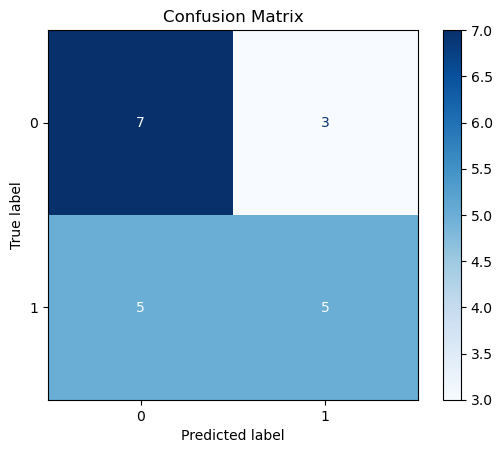

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt  # Also adding matplotlib import to be safe

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

AUC Score: 0.605


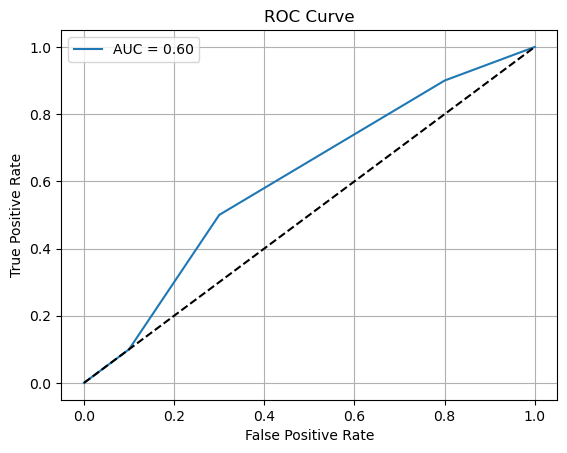

In [ ]:
# Import the required functions from scikit-learn
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt  # Also adding this import in case it's missing

# y_pred_proba gives probability for both classes. Take [:,1] for positive class
y_score = knn.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_score)
print("AUC Score:", auc_score)

# Optional: plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_score)
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1], 'k--')  # diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score
import numpy as np

# Step 1: Convert labels to binary matrix
classes = np.unique(y_test)

# Check if binary or multi-class classification
if len(classes) == 2:
    # For binary classification, use the raw probabilities of the positive class
    y_score = knn.predict_proba(X_test)[:, 1]  # Use probability of positive class only
    auc_score = roc_auc_score(y_test, y_score)
    print("AUC (binary):", auc_score)
else:
    # For multi-class, use label_binarize
    y_test_bin = label_binarize(y_test, classes=classes)
    y_score = knn.predict_proba(X_test)

    # Step 2: Calculate macro-average AUC
    auc_score = roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr")
    print("Macro-Averaged AUC (OvR):", auc_score)

AUC (binary): 0.605


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier


# KNN Tuning

In [ ]:
# Define your parameter grid
param_grid = {
    'n_neighbors': list(range(1, 21)),          # Try 1 to 20 neighbors
    'weights': ['uniform', 'distance'],         # Weight strategies
    'metric': ['euclidean', 'manhattan']        # Distance metrics
}

# Initialize model
knn = KNeighborsClassifier()

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit the search
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy Score:", grid_search.best_score_)


Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best Parameters: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
Best Accuracy Score: 0.6125


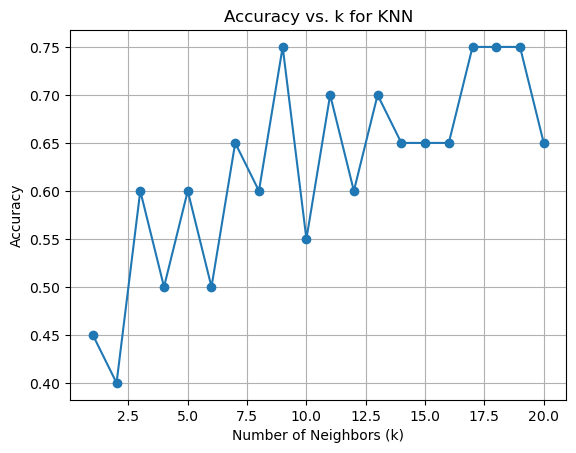

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

k_range = range(1, 21)
accuracies = []

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

plt.plot(k_range, accuracies, marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. k for KNN')
plt.grid(True)
plt.show()


# Prompts used:

- First prompt: The data has two components a folder names photos and a file names photos.json. Perform data preprocessing and build CNN model on it.

 - Last prompt:     replace this with something to use less RAM and donot use sample dataset.
 ```
X = np.load('/content/drive/MyDrive/Comp_Vis/X_images.npy')
y = np.load('/content/drive/MyDrive/Comp_Vis/y_labels.npy')
```

- first prompt- if someone built a dnn model, how can i go about evaluating it with confusion matrix and AUC.
 - last prompt- what else can be done to tune a model

- how do i make confusion matrix and AUC for CNN model.
 can you guide me to tune the model too

- NN Model build up: ROC paramter tuning and KNN implementation
- Evaluation of KNN model with AUC,ROC as classification reports
- First prompt : how to convert json file to csv.
  - Last prompt : multithreading in test and train
- How to build a dnn model for the given dataset
- Sample the dataset and build SVM model with it